,Total
Vendedor,
Diego Ramos,"R$ 284,401.90"
Ana Silva,"R$ 224,132.75"
Bruno Costa,"R$ 156,394.98"
Carla Mendes,"R$ 117,352.24"
Elena Souza,"R$ 113,617.71"


,Total
Cargo,
Vendedor Júnior,"R$ 284,401.90"
Vendedor Pleno,"R$ 273,747.22"
Vendedor Sênior,"R$ 224,132.75"
Gerente Regional,"R$ 113,617.71"


,Qtd_Estoque,Qtd_Minima,Investimento_Total
Produto,,,
Notebook,10,20,"R$ 57,184.80"
Teclado,15,30,"R$ 3,853.35"
Headset,9,19,"R$ 5,303.23"


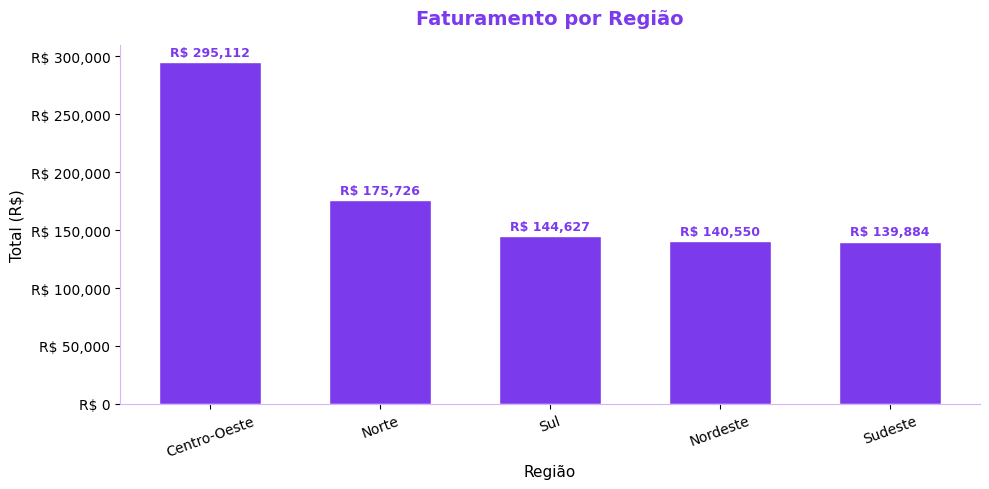

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
import os


COR_PRINCIPAL = '#7C3AED'
tabela_pos      = 'Purples'
tabela_neg    = 'RdPu'


caminho = 'empresa_dados.xlsx'
df_vendas = pd.read_excel(caminho, sheet_name='Vendas')
df_func = pd.read_excel(caminho, sheet_name='Funcionarios')
df_estoque = pd.read_excel(caminho, sheet_name='Estoque')

df_vendas['Total'] = (
    df_vendas['Quantidade'] * df_vendas['Preco_Unitario'] * (1 - df_vendas['Desconto_Pct'] / 100)
)

df_estoque['Margem_Pct'] = (
    (df_estoque['Preco_Venda'] - df_estoque['Preco_Custo']) / df_estoque['Preco_Venda'] * 100
).round(1)

df_estoque['Status'] = df_estoque.apply(
    lambda r: 'Sem Estoque' if r['Qtd_Estoque'] == 0
              else ('Estoque Baixo' if r['Qtd_Estoque'] < r['Qtd_Minima'] else 'OK'),
    axis=1
)

df_func['Anos_Empresa'] = df_func['Data_Admissao'].apply(
    lambda d: round((datetime.today() - pd.to_datetime(d)).days / 365, 1)
)

resumo_vendedor = (
    df_vendas.groupby('Vendedor')[['Total']]
    .sum()
    .sort_values('Total', ascending=False)
)
display(
    resumo_vendedor.style
    .format('R$ {:,.2f}')
    .background_gradient(cmap=tabela_pos)
    .set_caption("FATURAMENTO TOTAL POR VENDEDOR")
)

df_merge = pd.merge(
    df_vendas,
    df_func[['Nome', 'Cargo']],
    left_on='Vendedor', right_on='Nome',
    how='left'
)
resumo_cargo = (
    df_merge.groupby('Cargo')[['Total']]
    .sum()
    .sort_values('Total', ascending=False)
)
display(
    resumo_cargo.style
    .format('R$ {:,.2f}')
    .background_gradient(cmap=tabela_pos)
    .set_caption("FATURAMENTO TOTAL POR CARGO")
)

compras = df_estoque[df_estoque['Status'] != 'OK'].copy()

if not compras.empty:
    compras['Sugestão_Compra'] = (compras['Qtd_Minima'] * 2) - compras['Qtd_Estoque']
    compras['Investimento_Total'] = compras['Sugestão_Compra'] * compras['Preco_Custo']
    resumo_estoque = compras[['Produto', 'Qtd_Estoque', 'Qtd_Minima', 'Investimento_Total']].set_index('Produto')
    display(
        resumo_estoque.style
        .format({'Investimento_Total': 'R$ {:,.2f}'})
        .background_gradient(cmap=tabela_neg, subset=['Investimento_Total'])
        .set_caption("NECESSIDADE DE INVESTIMENTO (ESTOQUE BAIXO)")
    )
else:
    print("✅ TUDO EM DIA: Não há produtos abaixo do estoque mínimo.")

fat_regiao = df_vendas.groupby('Regiao')['Total'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fat_regiao.index, fat_regiao.values,
              color=COR_PRINCIPAL, edgecolor='white', width=0.6)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + fat_regiao.max() * 0.01,
        f"R$ {bar.get_height():,.0f}",
        ha='center', va='bottom', fontsize=9, fontweight='bold', color=COR_PRINCIPAL
    )

ax.set_title('Faturamento por Região', fontsize=14, fontweight='bold', pad=15, color=COR_PRINCIPAL)
ax.set_xlabel('Região', fontsize=11)
ax.set_ylabel('Total (R$)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.tick_params(axis='x', rotation=20)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#D8B4FE')
plt.tight_layout()
plt.show()

arquivo = 'Relatorio_Final.xlsx'
mode = 'a' if os.path.exists(arquivo) else 'w'

with pd.ExcelWriter(arquivo, engine='openpyxl', mode=mode, if_sheet_exists='replace') as writer:
    resumo_vendedor.to_excel(writer, sheet_name='Vendas_por_Vendedor')
    resumo_cargo.to_excel(writer, sheet_name='Vendas_por_Cargo')
    if not compras.empty:
        compras.to_excel(writer, sheet_name='Necessidade_Estoque', index=False)
with pd.ExcelWriter(arquivo, engine='openpyxl', mode=mode, if_sheet_exists='replace') as writer:
    resumo_vendedor.to_excel(writer, sheet_name='Vendas_por_Vendedor')
    resumo_cargo.to_excel(writer, sheet_name='Vendas_por_Cargo')
    if not compras.empty:
        compras.to_excel(writer, sheet_name='Necessidade_Estoque', index=False)